# Lorenz Attractor Synchronization Analysis

This notebook demonstrates synchronization analysis on the Lorenz attractor
using a source signal and its delayed version to find the delay.

In [1]:
import sys
sys.path.insert(0, '../src')

from synch_analysis import LorenzDataSource, SynchronizationPipeline

In [2]:
# Create Lorenz data source with known delay
lorenz = LorenzDataSource(
    a=10.0, b=28.0, c=8.0/3.0,
    initial_values=[0.01, 0, 0.3],
    iterations=5000,
    variable='x',
    delay_steps=150,  # True delay to recover (1.5 seconds at 100 Hz)
    noise_std=0.05,
    sampling_rate=100.0
)

In [3]:
# Run analysis pipeline
pipeline = SynchronizationPipeline(lorenz).run()

Loading data: Lorenz attractor: a=10.0, b=28.0, c=2.667, var=x, delay=150 steps, noise=0.05
  Signal A: Lorenz x (source) (5001 samples)
  Signal B: Lorenz x (delayed by 150 steps) (5001 samples)
Computing Hilbert transforms...
Computing Kuramoto order parameter...
  Mean R: 0.6011
  Sync ratio (R>0.8): 39.79%


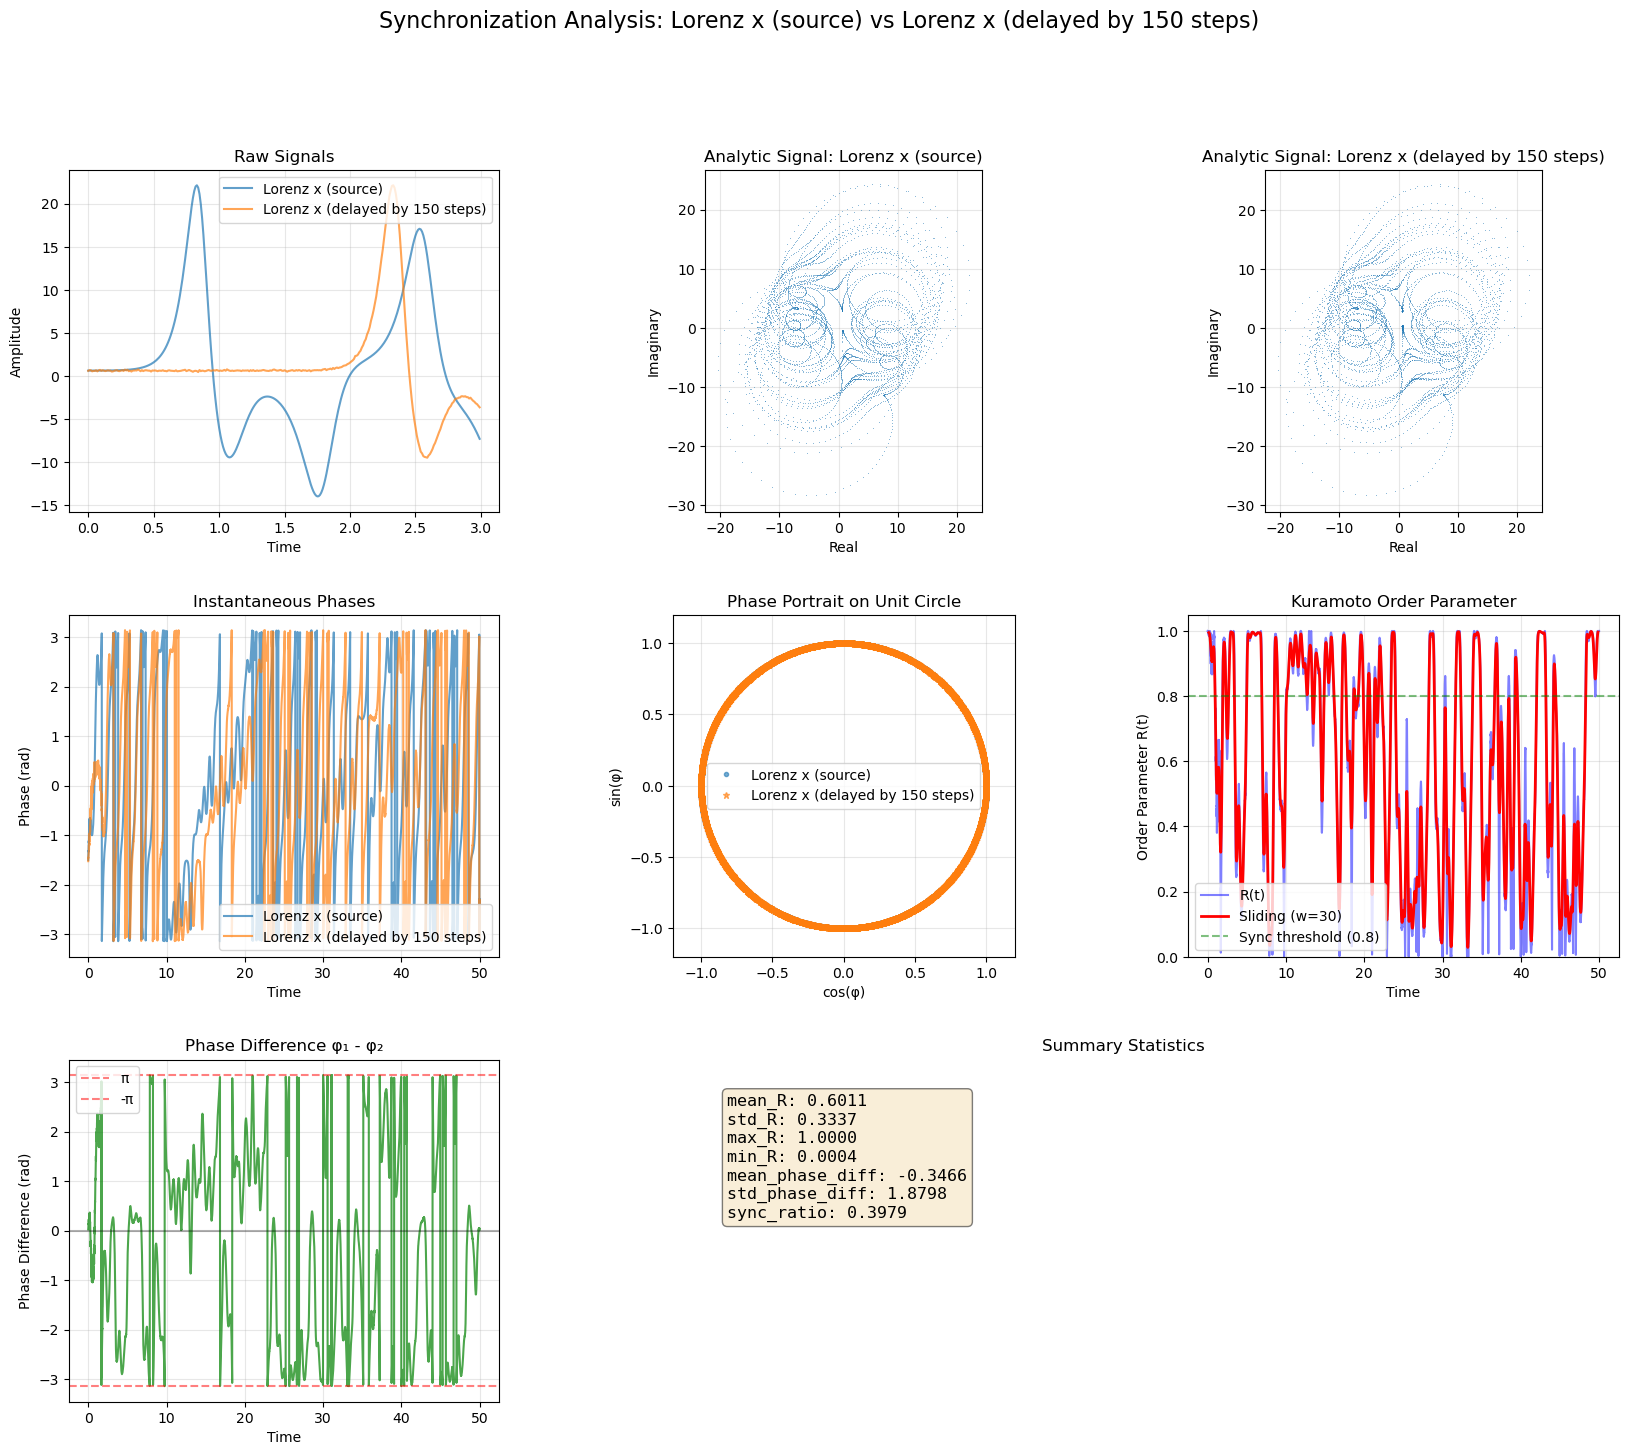

In [4]:
# View dashboard
fig = pipeline.plot_dashboard(sliding_window=30, n_signal_samples=300)

In [5]:
# Get statistics
stats = pipeline.get_stats()
for k, v in stats.items():
    print(f'{k}: {v:.4f}')

mean_R: 0.6011
std_R: 0.3337
max_R: 1.0000
min_R: 0.0004
mean_phase_diff: -0.3466
std_phase_diff: 1.8798
sync_ratio: 0.3979


In [6]:
# Export results
from synch_analysis import export_results
export_results(pipeline, '../results/lorenz_analysis/')

Results exported to ../results/lorenz_analysis//
